In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

from scipy.stats import zscore

import warnings
warnings.filterwarnings('ignore')

In [2]:
tech_supp_df = pd.read_csv('technical_support_data.csv')
tech_supp_df.head(3)

,PROBLEM_TYPE,no_of_cases,Avg_pending_calls,Avg_resol_time,recurrence_freq,Replace_percent,In_warranty_percent,Post_warranty_percent
0,Temperature control not working,170,1.3,32,0.04,0.0,75,25
1,power chord does not tightly fit,12,2.0,150,0.01,0.5,5,95
2,Fan swing not working,5,1.0,35,0.02,0.2,90,10


In [3]:
tech_supp_df.info()
tech_supp_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   PROBLEM_TYPE           23 non-null     object 
 1   no_of_cases            23 non-null     int64  
 2   Avg_pending_calls      23 non-null     float64
 3   Avg_resol_time         23 non-null     int64  
 4   recurrence_freq        23 non-null     float64
 5   Replace_percent        23 non-null     float64
 6   In_warranty_percent    23 non-null     int64  
 7   Post_warranty_percent  23 non-null     int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 1.6+ KB


(23, 8)

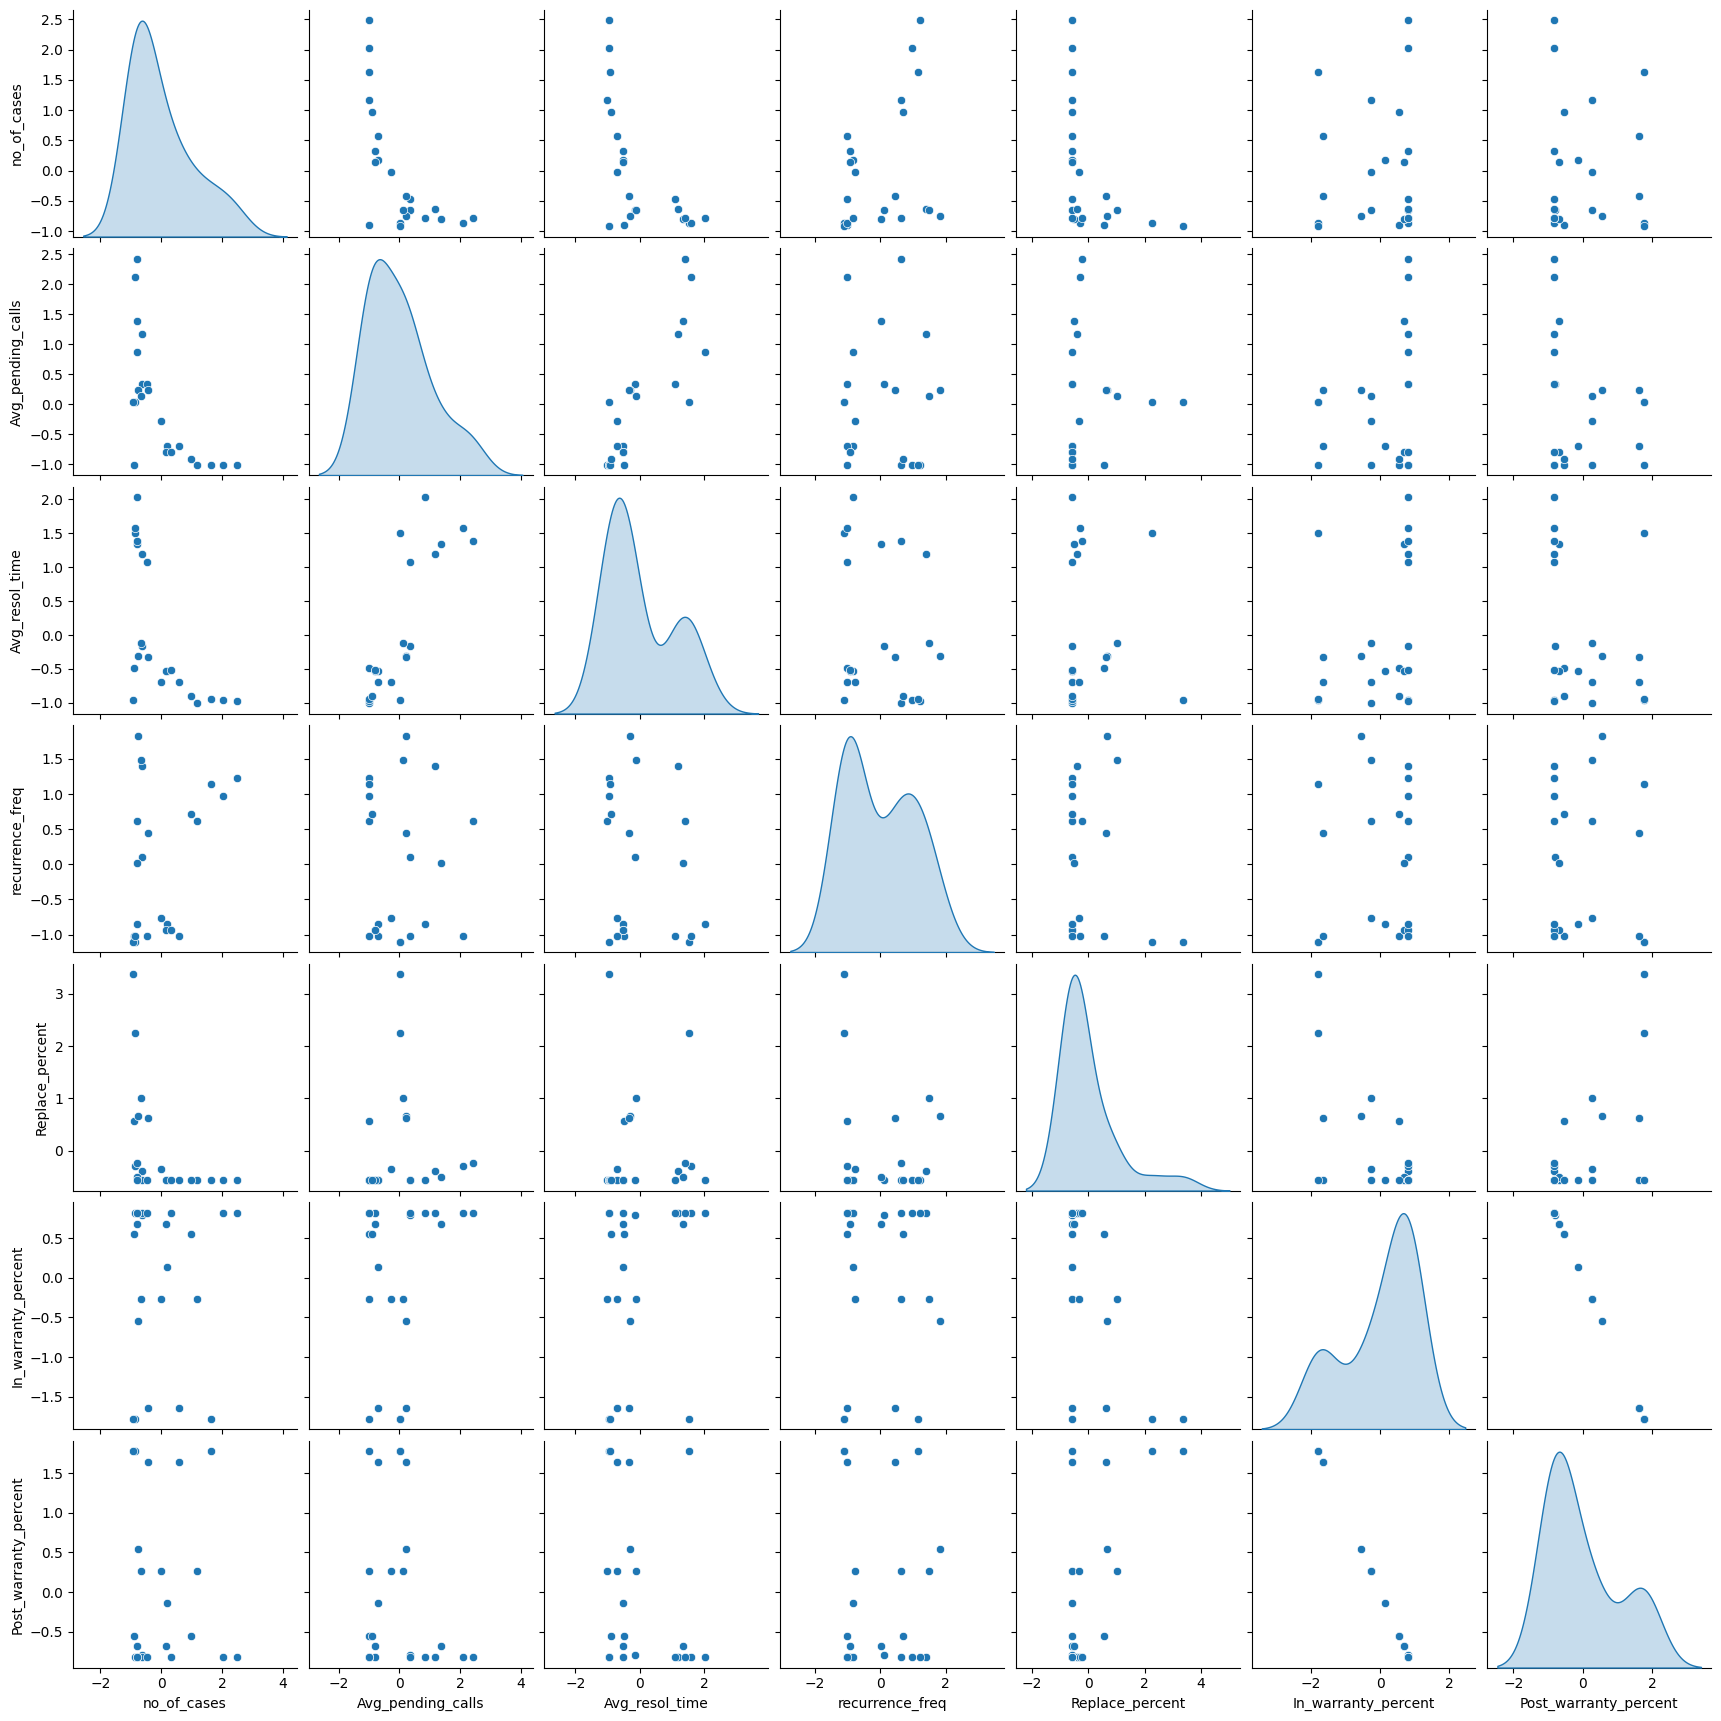

In [4]:
techSuppAttr = tech_supp_df.iloc[:,1:]
techSuppScaled = techSuppAttr.apply(zscore)
sns.pairplot(techSuppScaled, diag_kind='kde')
plt.show()

### Group Data into Similar Clusters

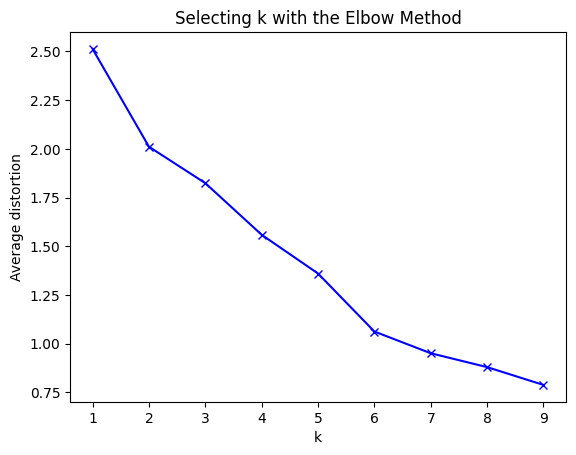

In [5]:
# find optimal number of clusters
from scipy.spatial.distance import cdist
clusters=range(1,10)
meanDistortions=[]

for k in clusters:
    model=KMeans(n_clusters=k).fit(techSuppScaled)
    prediction = model.predict(techSuppScaled)
    meanDistortions.append(sum(np.min(cdist(techSuppScaled, 
                                            model.cluster_centers_,
                                            'euclidean'),
                                            axis=1)) / 
                              techSuppScaled.shape[0])
plt.plot(clusters, meanDistortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Average distortion')
plt.title('Selecting k with the Elbow Method')
plt.show()

Though the bend is not coming out clearly as there are many bends, let us look at 3 clusters and 5 clusters

In [6]:
final_model=KMeans(3).fit(techSuppScaled)
prediction = final_model.predict(techSuppScaled)

tech_supp_df['GROUP'] = prediction
techSuppScaled['GROUP'] = prediction
print("Groups Assigned: \n")
tech_supp_df.head()

Groups Assigned: 



,PROBLEM_TYPE,no_of_cases,Avg_pending_calls,Avg_resol_time,recurrence_freq,Replace_percent,In_warranty_percent,Post_warranty_percent,GROUP
0,Temperature control not working,170,1.3,32,0.04,0.0,75,25,2
1,power chord does not tightly fit,12,2.0,150,0.01,0.5,5,95,1
2,Fan swing not working,5,1.0,35,0.02,0.2,90,10,2
3,Main switch does not on,3,2.0,8,0.01,0.7,5,95,1
4,Forgot mobile app password,45,2.3,54,0.15,0.0,99,1,0


### Analyze the distribution of the data among the 3 groups

In [7]:
# get the mean of the numeric fields grouped by GROUP
techSuppClust = tech_supp_df.groupby(['GROUP']).mean(numeric_only=True)
techSuppClust.head()

,no_of_cases,Avg_pending_calls,Avg_resol_time,recurrence_freq,Replace_percent,In_warranty_percent,Post_warranty_percent
GROUP,,,,,,,
0,35.000000,3.157143,132.571429,0.125714,0.021429,99.142857,0.857143
1,33.000000,2.100000,60.600000,0.174000,0.382000,26.000000,74.000000
2,261.272727,1.163636,19.818182,0.129091,0.021818,71.363636,28.636364


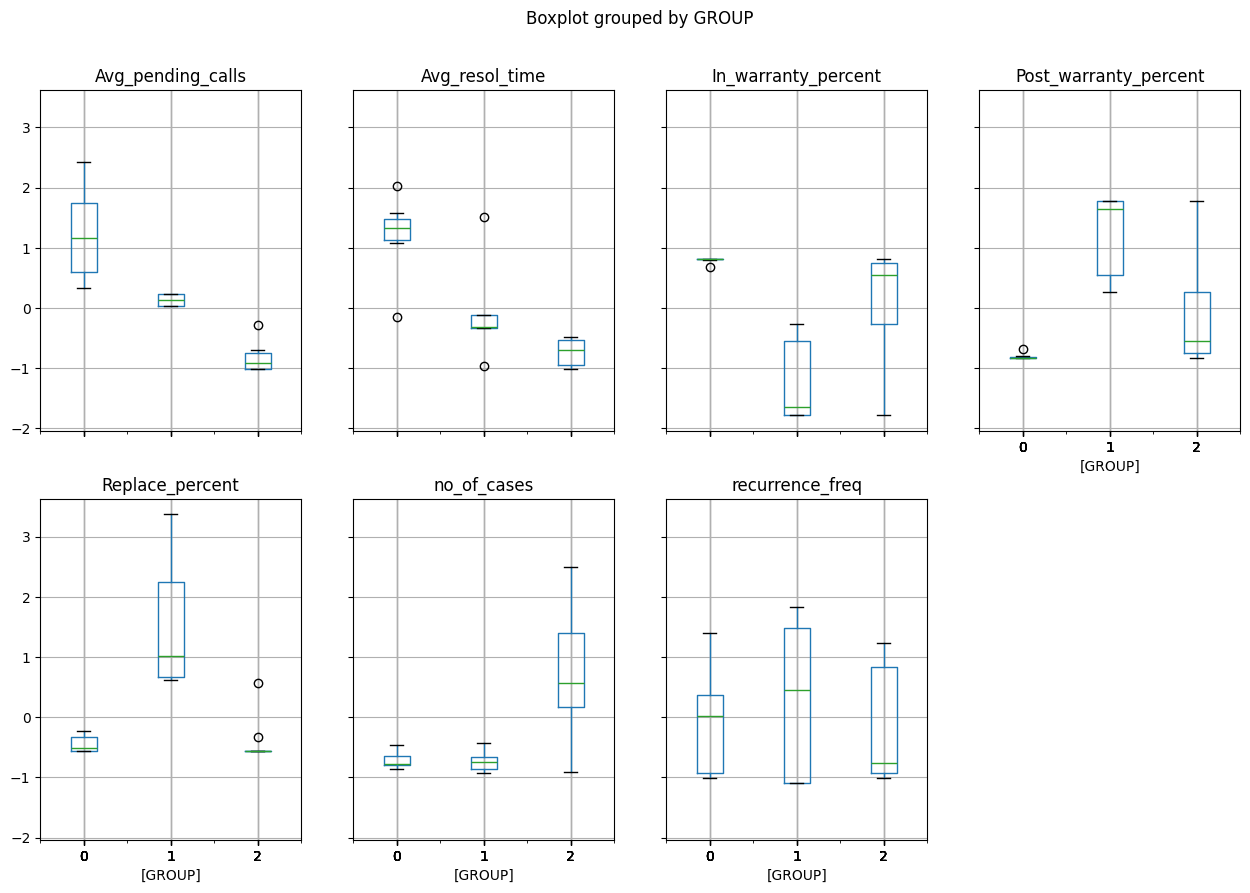

In [8]:
techSuppScaled.boxplot(by='GROUP', layout = (2,4),figsize=(15,10))
plt.show()

### Analyze the distribution of the data among the 5 groups

In [9]:
final_model = KMeans(5).fit(techSuppScaled)
prediction = final_model.predict(techSuppScaled)

tech_supp_df["GROUP"] = prediction
techSuppScaled["GROUP"] = prediction
print("Groups Assigned : \n")
tech_supp_df.head()

Groups Assigned : 



,PROBLEM_TYPE,no_of_cases,Avg_pending_calls,Avg_resol_time,recurrence_freq,Replace_percent,In_warranty_percent,Post_warranty_percent,GROUP
0,Temperature control not working,170,1.3,32,0.04,0.0,75,25,3
1,power chord does not tightly fit,12,2.0,150,0.01,0.5,5,95,2
2,Fan swing not working,5,1.0,35,0.02,0.2,90,10,3
3,Main switch does not on,3,2.0,8,0.01,0.7,5,95,2
4,Forgot mobile app password,45,2.3,54,0.15,0.0,99,1,1


In [10]:
# get the mean of the numeric fields grouped by GROUP
techSuppClust = tech_supp_df.groupby(['GROUP']).mean(numeric_only=True)
techSuppClust.head()

,no_of_cases,Avg_pending_calls,Avg_resol_time,recurrence_freq,Replace_percent,In_warranty_percent,Post_warranty_percent
GROUP,,,,,,,
0,395.250000,1.025000,7.750000,0.240000,0.000000,87.500000,12.500000
1,38.250000,2.850000,128.250000,0.057500,0.012500,99.750000,0.250000
2,112.142857,1.828571,47.857143,0.165714,0.272857,20.714286,79.285714
3,134.600000,1.280000,31.000000,0.034000,0.048000,84.000000,16.000000
4,30.666667,3.566667,138.333333,0.216667,0.033333,98.333333,1.666667


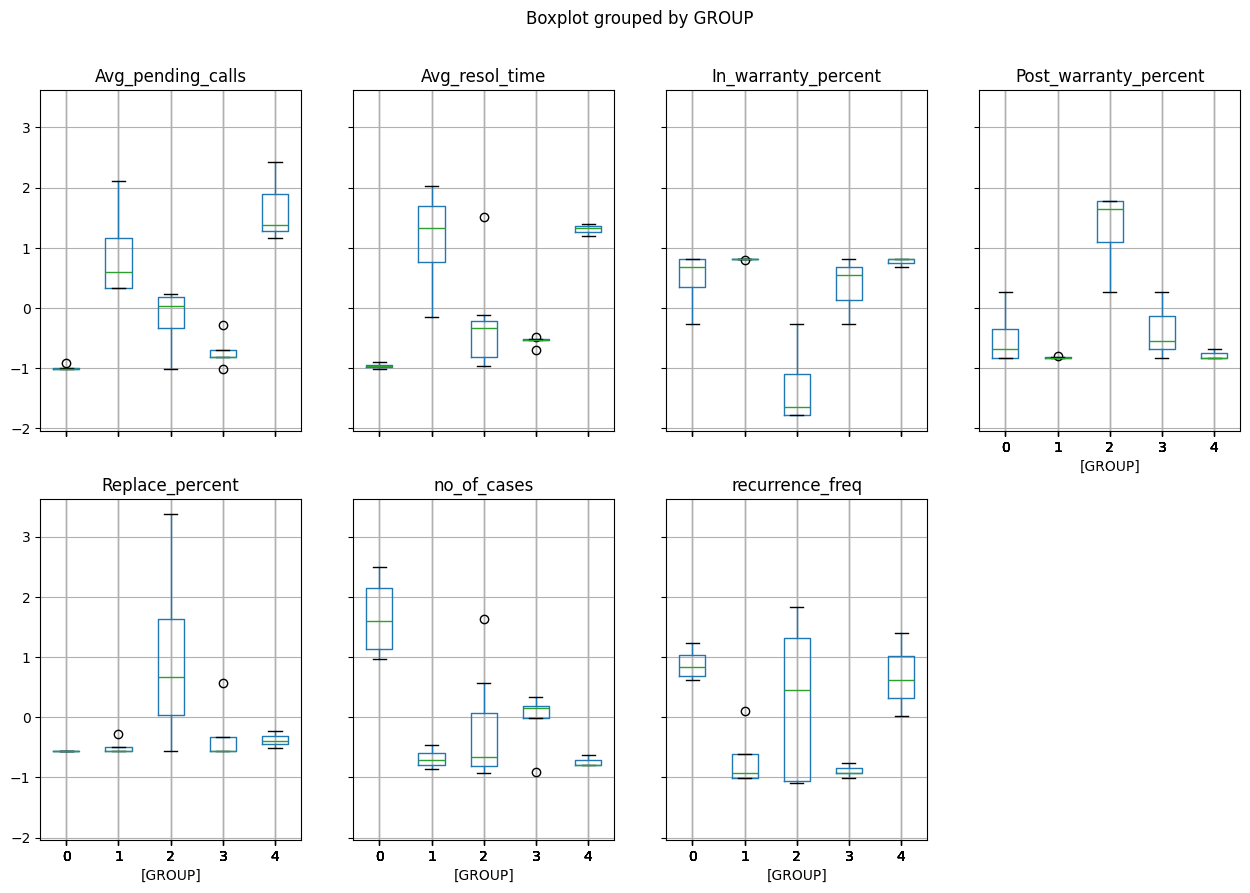

In [11]:
techSuppScaled.boxplot(by='GROUP', layout = (2,4),figsize=(15,10))
plt.show()